In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_pickle('submission_data.pkl')
print("Shape of the dataset:", df.shape)

Shape of the dataset: (1618, 107)


In [3]:
print("Column data types:")
print(df.dtypes)
missing = df.isnull().sum()
print("Missing values in each column:")
print(missing)
print("\nTotal missing values:", missing.sum())

Column data types:
Sno                   int64
Lecture               int64
StudentNo             int64
Total_Characters      int64
Total_Words           int64
                     ...   
x_96                float64
x_97                float64
x_98                float64
x_99                float64
x_100               float64
Length: 107, dtype: object
Missing values in each column:
Sno                 0
Lecture             0
StudentNo           0
Total_Characters    0
Total_Words         0
                   ..
x_96                0
x_97                0
x_98                0
x_99                0
x_100               0
Length: 107, dtype: int64

Total missing values: 0


In [4]:
df['target'] = 0
df.loc[df['Submission_Delay'] > 0, 'target'] = 1

print("Target column created.")
print("0 = On Time, 1 = Late")
print(df['target'].value_counts())

Target column created.
0 = On Time, 1 = Late
target
0    1398
1     220
Name: count, dtype: int64


C:\Users\nisar\AppData\Local\Temp\ipykernel_21000\3477796459.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['target'] = 0


In [5]:
df = df.drop(columns=['Submission_Delay'])
print("Submission_Delay column dropped.")
print("New shape:", df.shape)

Submission_Delay column dropped.
New shape: (1618, 107)


In [6]:
feature_cols = [col for col in df.columns if col.startswith('x_')]
print("Number of feature columns:", len(feature_cols))

print("\nChecking scale differences before normalization:")
print(df[feature_cols].describe().loc[['mean', 'std', 'min', 'max']])

Number of feature columns: 100

Checking scale differences before normalization:
          x_01      x_02      x_03      x_04      x_05      x_06      x_07  \
mean -0.180653  0.247044  0.077171  0.034769  0.082283 -0.507741  0.150273   
std   0.078789  0.070461  0.066886  0.080642  0.084528  0.097695  0.048011   
min  -0.449366  0.055804 -0.045895 -0.157097 -0.158241 -0.830079  0.043145   
max  -0.030599  0.454263  0.231516  0.197526  0.284643 -0.148969  0.304651   

          x_08      x_09      x_10  ...      x_91      x_92      x_93  \
mean  0.674324 -0.274522 -0.192381  ...  0.451521  0.177854 -0.011085   
std   0.109727  0.081957  0.106041  ...  0.115518  0.073626  0.044053   
min   0.238888 -0.505215 -0.572155  ...  0.151375  0.048556 -0.116067   
max   1.052676 -0.051664 -0.044506  ...  0.787647  0.453539  0.104649   

          x_94      x_95      x_96      x_97      x_98      x_99     x_100  
mean  0.064060  0.552460  0.344273  0.132666 -0.313386  0.147997 -0.114386  
std   0.

In [7]:
for col in feature_cols:
    mean = df[col].mean()
    std = df[col].std()
    df[col] = (df[col] - mean) / std

print("Normalization done.")
print("\nMeans after normalization (should all be ~0):")
print(df[feature_cols].mean().describe())

Normalization done.

Means after normalization (should all be ~0):
count    1.000000e+02
mean     9.639316e-18
std      3.082693e-16
min     -1.440408e-15
25%     -9.222125e-17
50%      1.756595e-17
75%      1.405276e-16
max      7.026381e-16
dtype: float64


In [9]:
correlations = df[feature_cols].corrwith(df['target'])
print(correlations)

x_01    -0.001304
x_02     0.035862
x_03    -0.013065
x_04    -0.065493
x_05     0.060733
           ...   
x_96    -0.021038
x_97     0.005254
x_98    -0.023842
x_99    -0.007503
x_100    0.039395
Length: 100, dtype: float64


In [10]:
top_15 = correlations.abs().sort_values(ascending=False).head(15)
top_15_cols = top_15.index.tolist()
print("Top 15 features:")
print(top_15_cols)

Top 15 features:
['x_04', 'x_05', 'x_54', 'x_74', 'x_84', 'x_19', 'x_52', 'x_25', 'x_100', 'x_38', 'x_02', 'x_86', 'x_48', 'x_53', 'x_61']


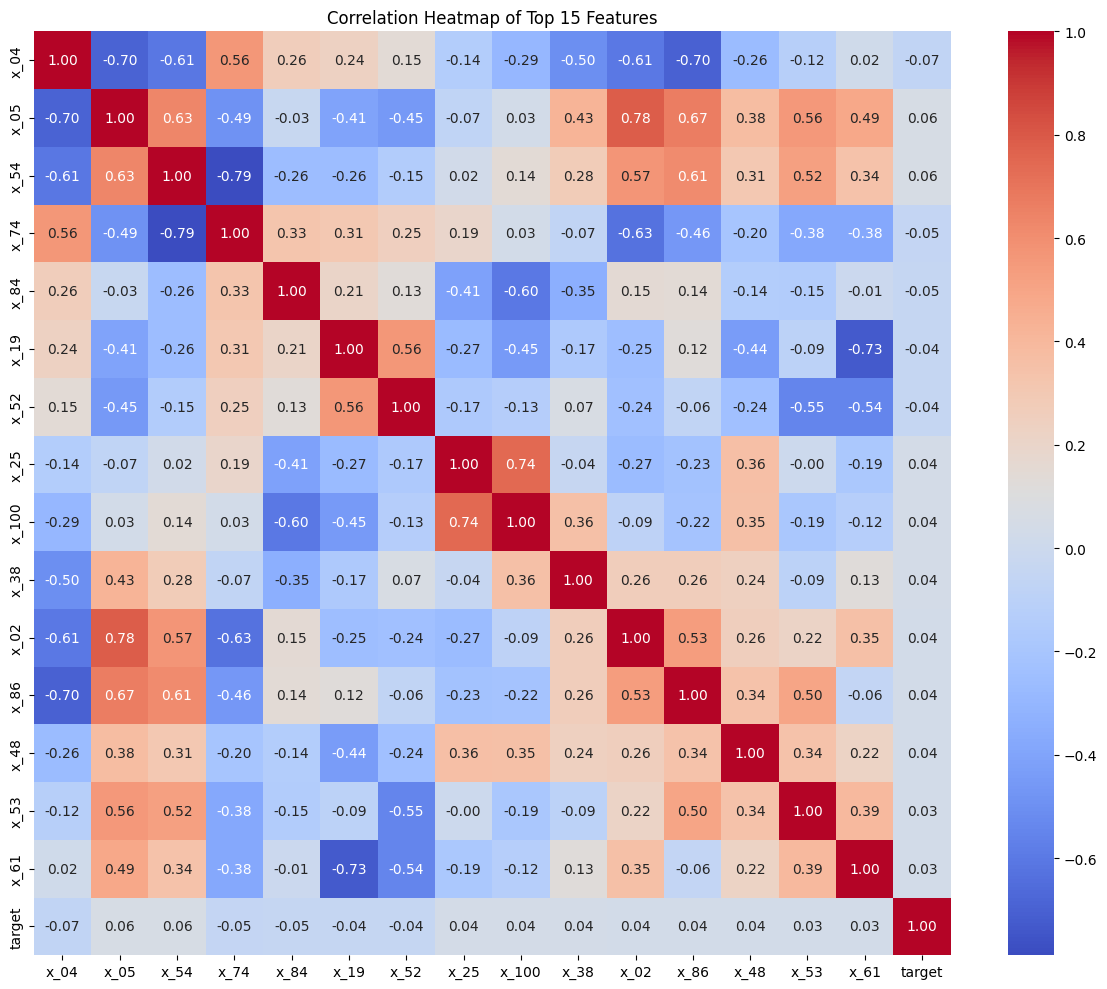

In [13]:
top_15_df = df[top_15_cols + ['target']]
corr_matrix = top_15_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Heatmap of Top 15 Features")
plt.tight_layout()
plt.show()

In [14]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42)
tsne_result = tsne.fit_transform(df[feature_cols])

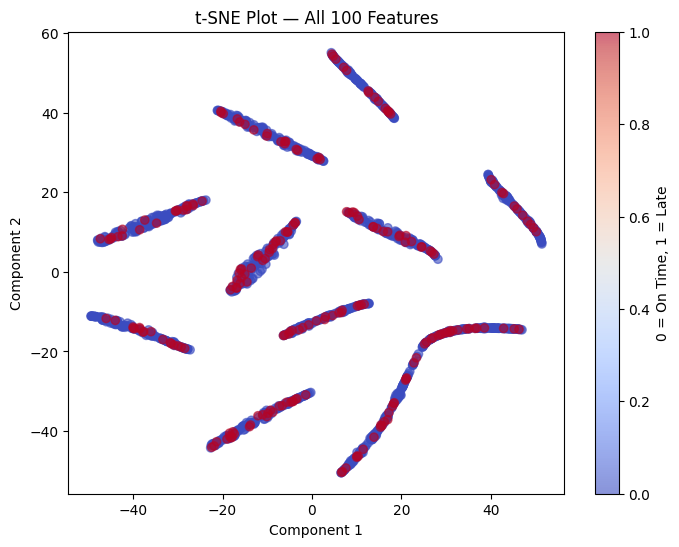

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(tsne_result[:, 0], tsne_result[:, 1], c=df['target'], cmap='coolwarm', alpha=0.6)
plt.colorbar(label='0 = On Time, 1 = Late')
plt.title("t-SNE Plot — All 100 Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [16]:
from umap import UMAP

umap_model = UMAP(n_components=2, random_state=42)
umap_result = umap_model.fit_transform(df[feature_cols])

c:\Users\nisar\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


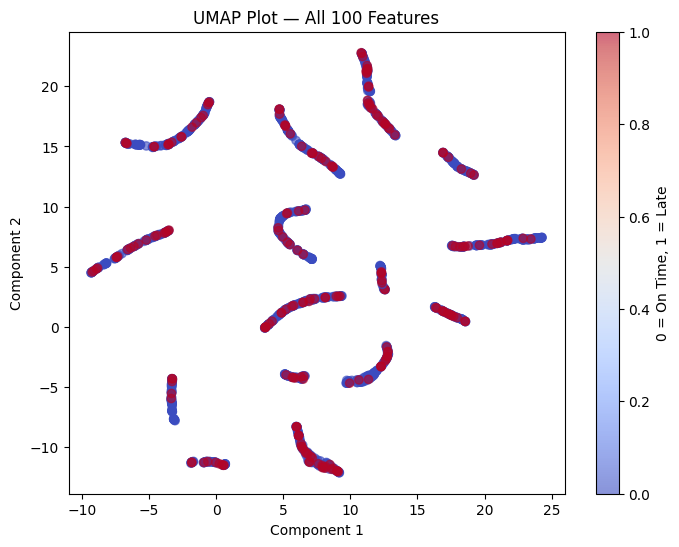

In [17]:
plt.figure(figsize=(8, 6))
plt.scatter(umap_result[:, 0], umap_result[:, 1], c=df['target'], cmap='coolwarm', alpha=0.6)
plt.colorbar(label='0 = On Time, 1 = Late')
plt.title("UMAP Plot — All 100 Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [18]:
umap_model_15 = UMAP(n_components=2, random_state=42)
umap_result_15 = umap_model_15.fit_transform(df[top_15_cols])

c:\Users\nisar\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


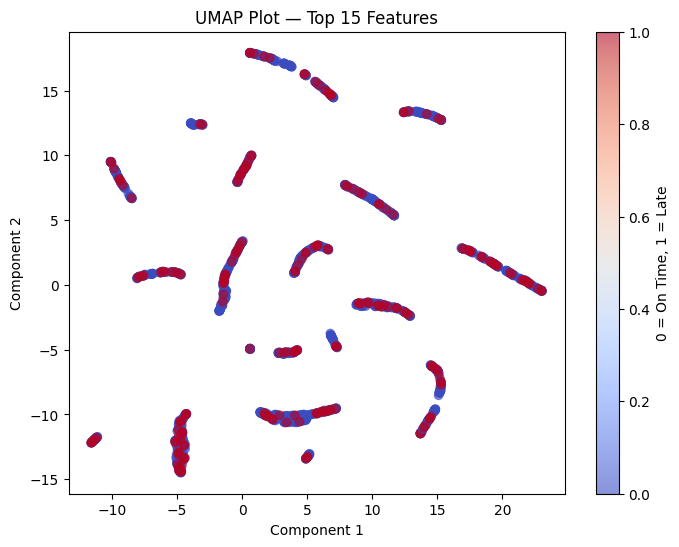

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(umap_result_15[:, 0], umap_result_15[:, 1], c=df['target'], cmap='coolwarm', alpha=0.6)
plt.colorbar(label='0 = On Time, 1 = Late')
plt.title("UMAP Plot — Top 15 Features")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score

X = df[top_15_cols]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (1294, 15)
Testing size: (324, 15)


In [25]:
lr = LogisticRegression(class_weight='balanced')
lr.fit(X_train, y_train)

svc = SVC(probability=True, class_weight='balanced')
svc.fit(X_train, y_train)

rf = RandomForestClassifier(random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

print("All 3 models trained.")

All 3 models trained.


In [26]:
models = {'Logistic Regression': lr, 'SVC': svc, 'Random Forest': rf}

print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'AUC-ROC':<12}")
print("-" * 85)

for name, model in models.items():
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]
    report = classification_report(y_test, preds, output_dict=True)
    
    accuracy = round(report['accuracy'], 4)
    precision = round(report['1']['precision'], 4)
    recall = round(report['1']['recall'], 4)
    f1 = round(report['1']['f1-score'], 4)
    auc = round(roc_auc_score(y_test, probs), 4)
    
    print(f"{name:<25} {accuracy:<12} {precision:<12} {recall:<12} {f1:<12} {auc:<12}")

Model                     Accuracy     Precision    Recall       F1-Score     AUC-ROC     
-------------------------------------------------------------------------------------
Logistic Regression       0.5432       0.125        0.45         0.1957       0.5101      
SVC                       0.5494       0.1268       0.45         0.1978       0.5371      
Random Forest             0.8488       0.0          0.0          0.0          0.5053      


In [27]:
X_all = df[feature_cols]

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(X_all, y, test_size=0.2, random_state=42)

lr_all = LogisticRegression(class_weight='balanced')
lr_all.fit(X_train_all, y_train_all)

svc_all = SVC(probability=True, class_weight='balanced')
svc_all.fit(X_train_all, y_train_all)

rf_all = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_all.fit(X_train_all, y_train_all)

models_all = {'Logistic Regression': lr_all, 'SVC': svc_all, 'Random Forest': rf_all}

print("All 100 features:")
print(f"{'Model':<25} {'Accuracy':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12} {'AUC-ROC':<12}")
print("-" * 85)

for name, model in models_all.items():
    preds = model.predict(X_test_all)
    probs = model.predict_proba(X_test_all)[:, 1]
    report = classification_report(y_test_all, preds, output_dict=True)
    
    accuracy = round(report['accuracy'], 4)
    precision = round(report['1']['precision'], 4)
    recall = round(report['1']['recall'], 4)
    f1 = round(report['1']['f1-score'], 4)
    auc = round(roc_auc_score(y_test_all, probs), 4)
    
    print(f"{name:<25} {accuracy:<12} {precision:<12} {recall:<12} {f1:<12} {auc:<12}")

All 100 features:
Model                     Accuracy     Precision    Recall       F1-Score     AUC-ROC     
-------------------------------------------------------------------------------------
Logistic Regression       0.5278       0.1307       0.5          0.2073       0.5307      
SVC                       0.5216       0.1338       0.525        0.2132       0.5188      
Random Forest             0.8488       0.0909       0.025        0.0392       0.5031      
